In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

In [2]:
data = pd.read_csv(r'D:/Python/DATA/New/samplesuperstore.csv')

In [3]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [5]:
data.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
data.shape

(10194, 21)

In [7]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [8]:
data['Category'].unique()

array(['Office Supplies', 'Furniture', 'Technology'], dtype=object)

In [9]:
data['Category'].value_counts()

Category
Office Supplies    6128
Furniture          2201
Technology         1865
Name: count, dtype: int64

In [10]:
data['Sub-Category'].value_counts()

Sub-Category
Binders        1548
Paper          1384
Furnishings    1009
Phones          903
Storage         856
Art             821
Accessories     775
Chairs          634
Appliances      474
Labels          368
Tables          326
Envelopes       256
Bookcases       232
Fasteners       229
Supplies        192
Machines        117
Copiers          70
Name: count, dtype: int64

In [11]:
data['Region'].value_counts()

Region
West       3253
East       2986
Central    2335
South      1620
Name: count, dtype: int64

In [12]:
data['Country/Region'].value_counts()

Country/Region
United States    9994
Canada            200
Name: count, dtype: int64

In [13]:
data['City'].value_counts()

City
New York City    915
Los Angeles      747
Philadelphia     537
San Francisco    510
Seattle          428
                ... 
Whittier           1
Abilene            1
Palatine           1
Port Orange        1
Danbury            1
Name: count, Length: 542, dtype: int64

In [14]:
data['Sales'].sum()

np.float64(2326534.3543)

In [15]:
data['Profit'].sum()

np.float64(292296.8146)

In [16]:
data['Sales'].mean()

np.float64(228.22585386501862)

In [17]:
data.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64

In [18]:
data.groupby('Category')['Profit'].sum().sort_values(ascending=False)

Category
Technology         146543.3756
Office Supplies    126023.4434
Furniture           19729.9956
Name: Profit, dtype: float64

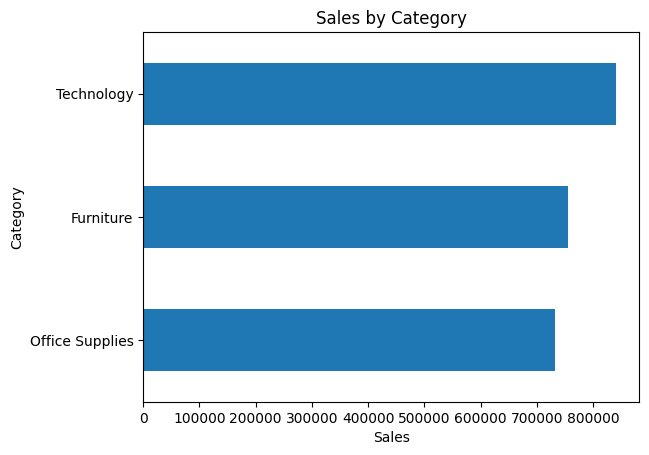

In [19]:
sales_by_cat = data.groupby('Category')['Sales'].sum().sort_values()
sales_by_cat.plot(kind='barh')
plt.title('Sales by Category')
plt.xlabel('Sales')
plt.ylabel('Category')
plt.show()

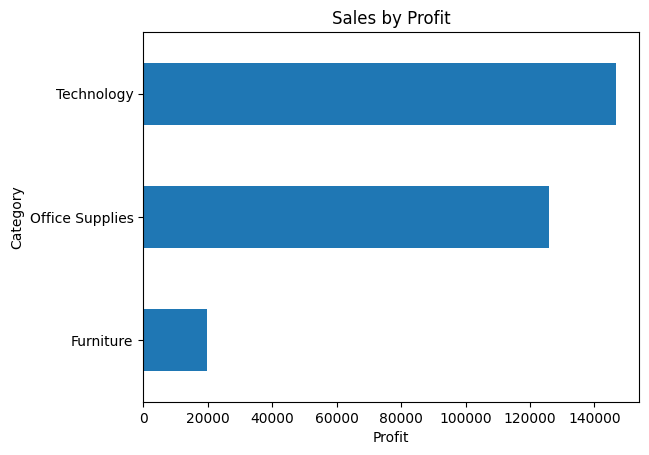

In [20]:
profit_by_cat = data.groupby('Category')['Profit'].sum().sort_values()
profit_by_cat.plot(kind='barh')
plt.title('Sales by Profit')
plt.xlabel('Profit')
plt.ylabel('Category')
plt.show()

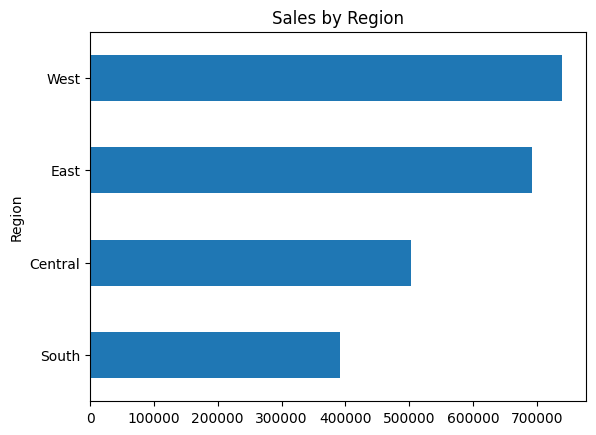

In [21]:
data.groupby("Region")["Sales"].sum().sort_values().plot(kind="barh")
plt.title("Sales by Region")
plt.show()

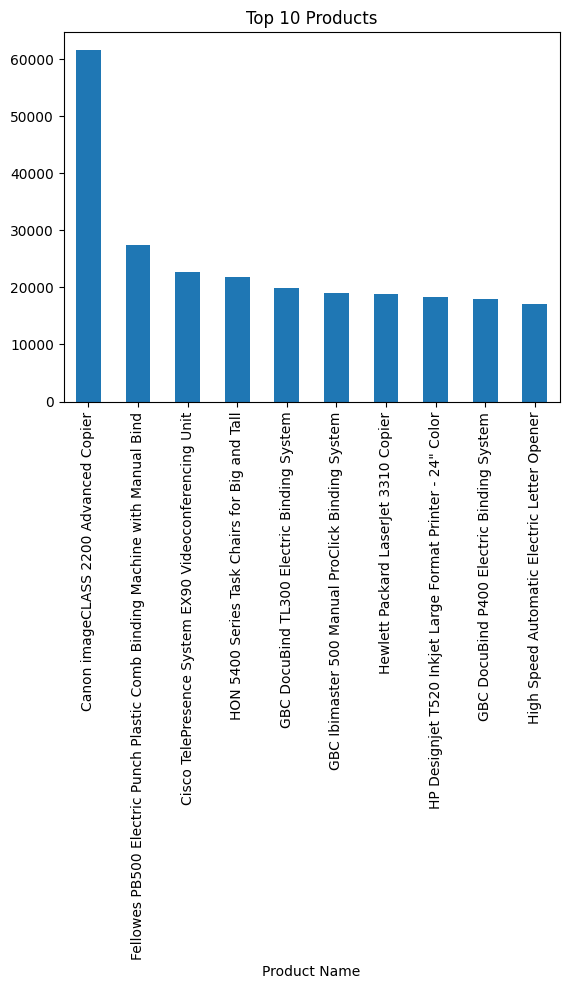

In [22]:
top_products = (
    data.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(kind="bar")

plt.title("Top 10 Products")
plt.show()

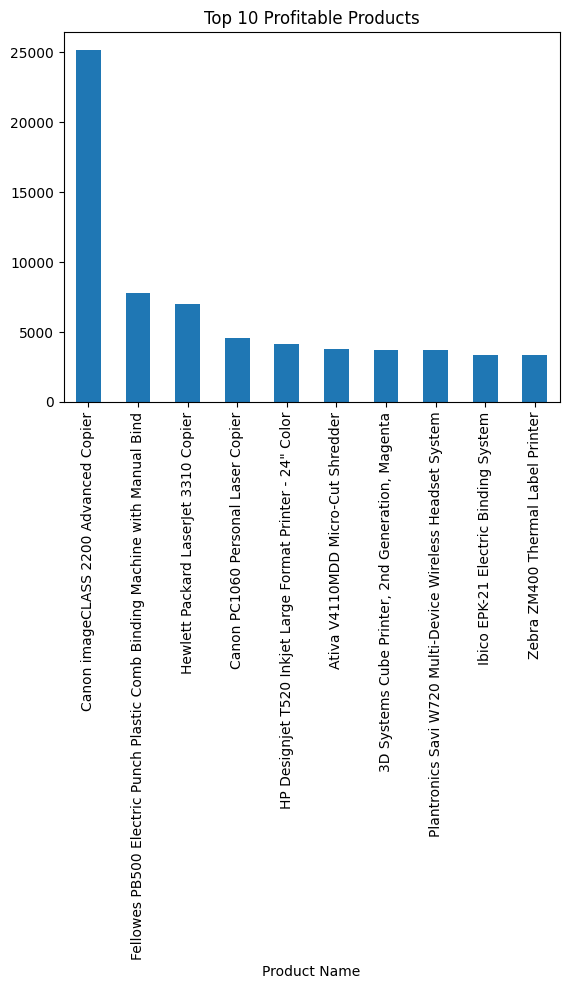

In [23]:
top_profit = (
    data.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_profit.plot(kind="bar")

plt.title("Top 10 Profitable Products")
plt.show()

In [24]:
product_profit = (
    data.groupby("Product Name")["Profit"]
    .sum()
    .sort_values()
)
product_profit.head(10)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

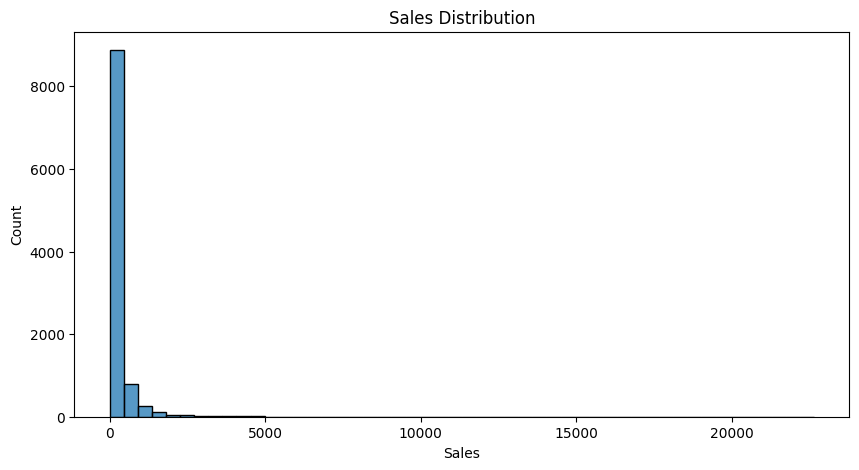

In [25]:
plt.figure(figsize=(10,5))
sns.histplot(data['Sales'],bins=50)
plt.title('Sales Distribution')
plt.show()

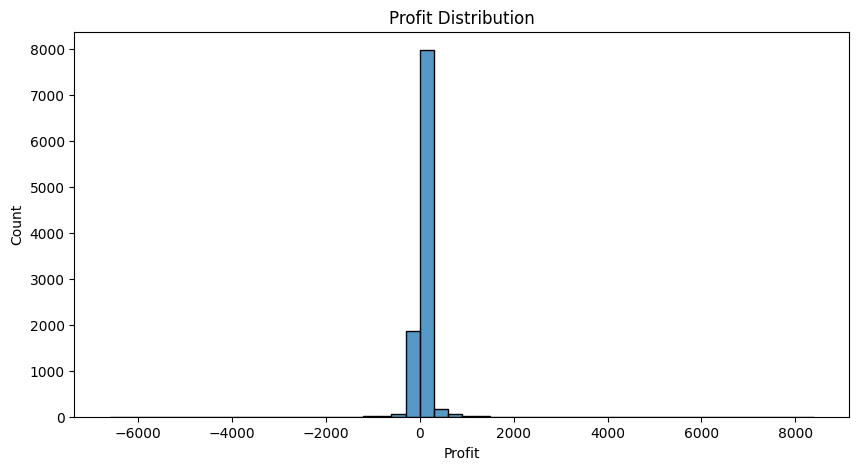

In [26]:
plt.figure(figsize=(10,5))
sns.histplot(data['Profit'],bins=50)
plt.title('Profit Distribution')
plt.show()

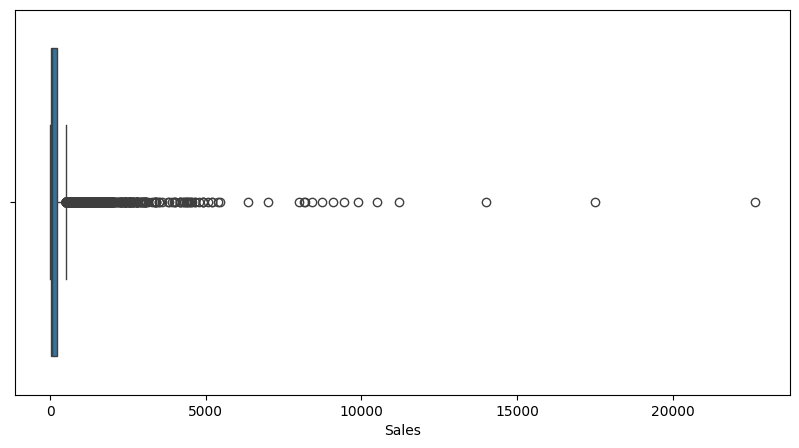

In [27]:
plt.figure(figsize=(10,5))
sns.boxplot(x=data["Sales"])
plt.show()

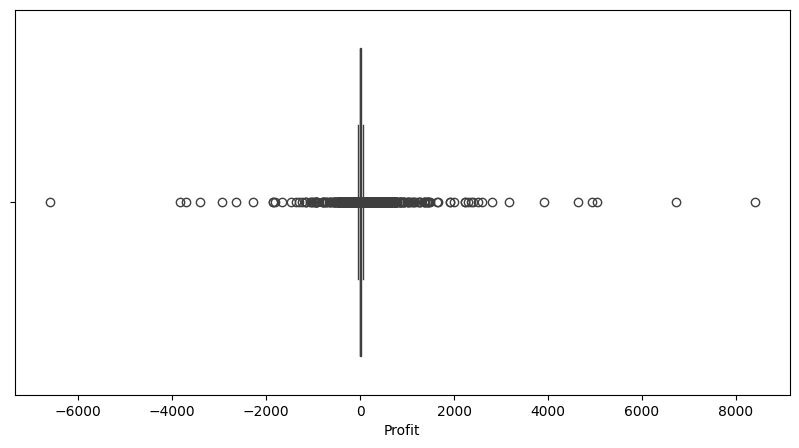

In [28]:
plt.figure(figsize=(10,5))
sns.boxplot(x=data["Profit"])
plt.show()

In [29]:
corr = data[
    ['Sales','Profit','Quantity','Discount']
].corr()

corr

,Sales,Profit,Quantity,Discount
Sales,1.000000,0.481460,0.198457,-0.027756
Profit,0.481460,1.000000,0.066145,-0.218882
Quantity,0.198457,0.066145,1.000000,0.007475
Discount,-0.027756,-0.218882,0.007475,1.000000


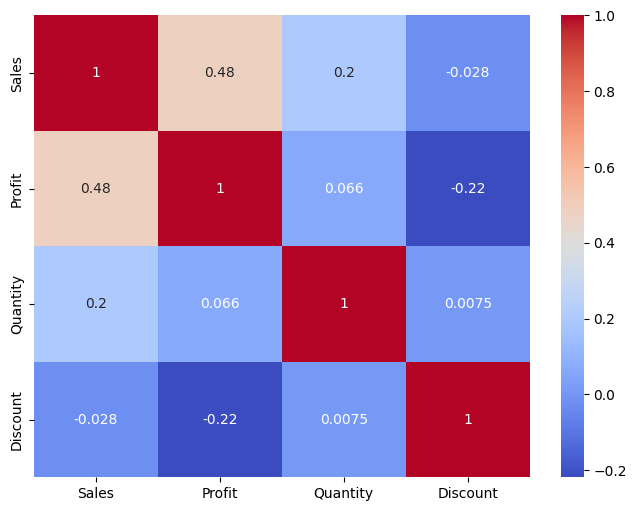

In [30]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr , 
    annot=True ,
    cmap='coolwarm'    
)

plt.show()

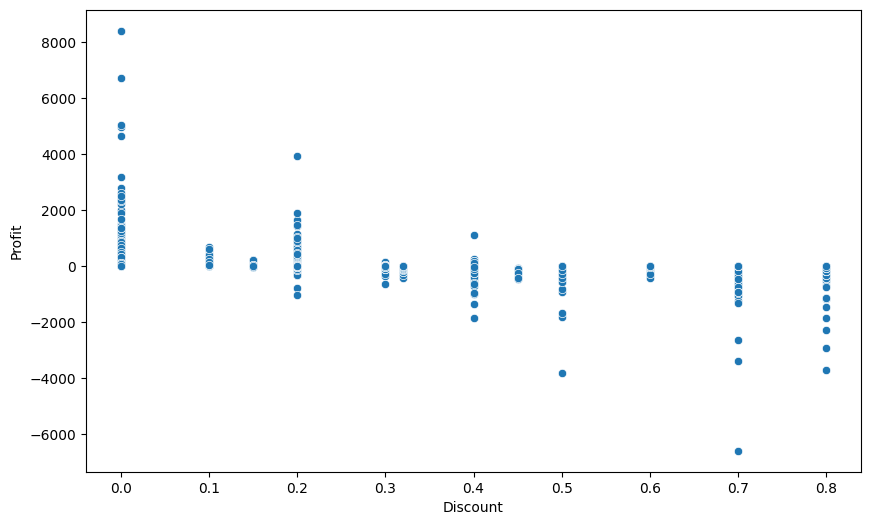

In [31]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=data,
    x="Discount",
    y="Profit"
)

plt.show()

In [32]:
x = data[['Sales','Quantity','Discount']]
y = data['Profit']

In [33]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

In [34]:
model = LinearRegression()
model.fit(x_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
y_pred = model.predict(x_test)

In [36]:
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.3998152568232861
61.33662679673414


In [37]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

In [38]:
data['month'] = data['Order Date'].dt.month

In [39]:
data['year'] = data['Order Date'].dt.year

In [40]:
data_encoded = pd.get_dummies(data , columns=['Category','Region'] , drop_first=True)

In [41]:
features = ['Sales','Quantity','Discount','month','year']

In [42]:
features += [col 
             for col in data_encoded.columns
             if col.startswith('Category_')
             or col.startswith('Region_')
            ]

In [43]:
x = data_encoded[features]
y = data_encoded['Profit']

In [44]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

In [45]:
model = LinearRegression()
model.fit(x_train , y_train)
y_pred = model.predict(x_test)

In [46]:
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.41036206881342263
61.32204893765719


In [47]:
rf = RandomForestRegressor(n_estimators=100 , random_state=42)

In [ ]:
rf.fit(x_train , y_train)

In [ ]:
y_pred_rf = rf.predict(x_test)

In [ ]:
print(r2_score(y_test,y_pred_rf))
print(mean_absolute_error(y_test,y_pred_rf))

In [ ]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_})

importance = importance.sort_values(
    by='Importance',
    ascending=False)

print(importance)

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature')

plt.show()

In [ ]:
train_score = rf.score(x_train, y_train)
test_score = rf.score(x_test, y_test)

print('Train:', train_score)
print('Test :', test_score)

In [ ]:
scores = cross_val_score(
    rf,
    x,
    y,
    cv=5,
    scoring='r2')

print(scores)
print(scores.mean())